In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pytorch_dataset import EBSDStrainDataset

class MultiModalEBSDStrainCNN(nn.Module):
    def __init__(self, euler_dim=3):
        super(MultiModalEBSDStrainCNN, self).__init__()

        resnet = models.resnet18(weights=None)

        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity()

        self.image_features = nn.Sequential(*list(resnet.children())[:-1])

        self.euler_processor = nn.Sequential(
            nn.Linear(euler_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 + 64, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x, eulers):
        img_features = self.image_features(x)
        img_features = torch.flatten(img_features, 1)

        euler_features = self.euler_processor(eulers)

        combined = torch.cat((img_features, euler_features), dim=1)
        out = self.classifier(combined)
        return out.squeeze()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Using device: cpu
Testing indices from 0 to 1199 (dataset size: 1200)

--- Range stats [0:1199] ---
Mean absolute error: 0.7396
Std of absolute error: 0.5464
Min / Max absolute error: 0.0015 / 2.9552


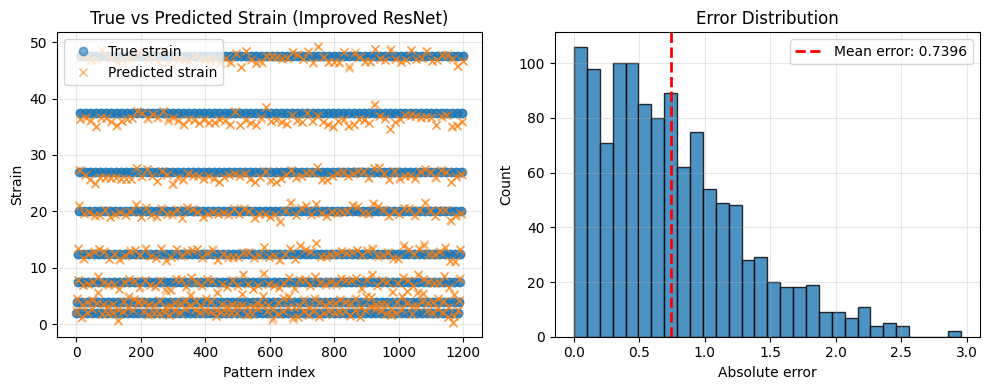


6 worst-error patterns at indices: [973, 972, 1164, 1171, 1170, 60]


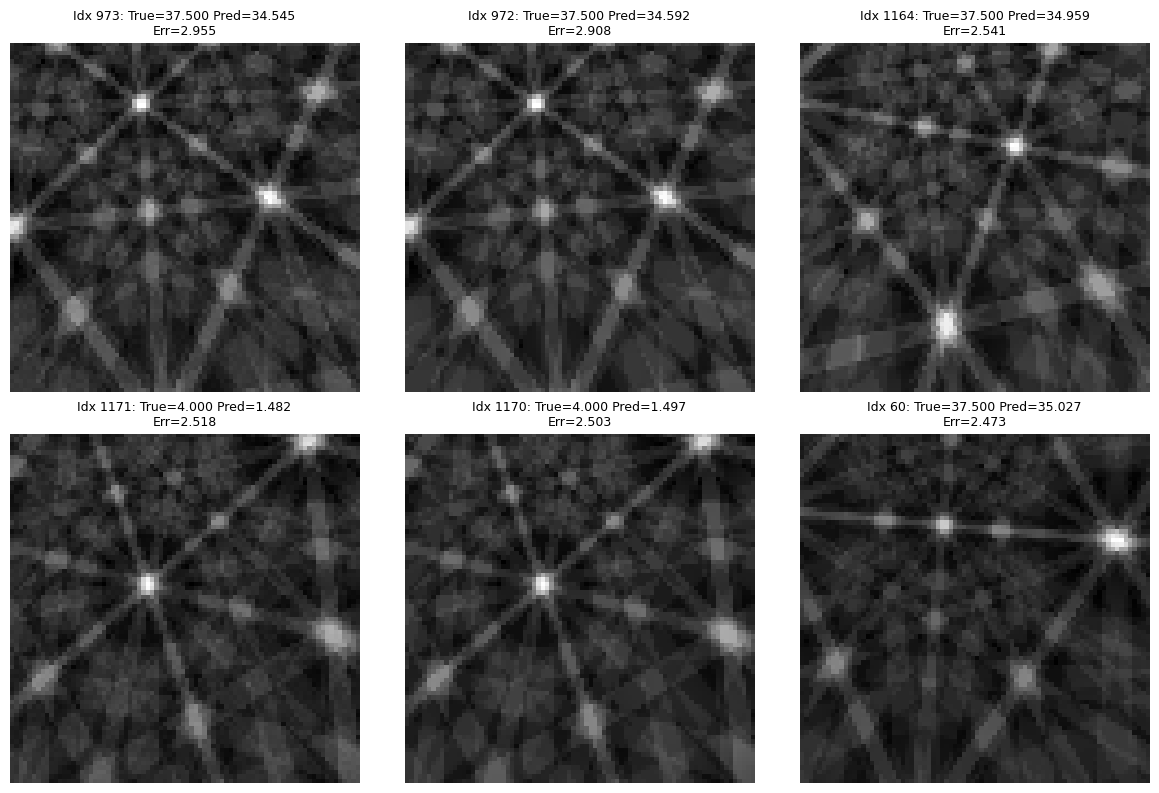

In [2]:
%matplotlib inline

# ----- CONFIG -----
h5_path = "/content/drive/MyDrive/ebsd_fcc_fe.h5"
model_path = "/content/drive/MyDrive/best_ebsd_strain_model.pth"
start_idx = 0
end_idx = 1199

num_examples_to_show = 6
# -------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

test_dataset = EBSDStrainDataset(h5_path=h5_path, split="test")
dataset_len = len(test_dataset)
end_idx = min(end_idx, dataset_len - 1)
print(f"Testing indices from {start_idx} to {end_idx} (dataset size: {dataset_len})")

model = MultiModalEBSDStrainCNN(euler_dim=3).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

true_strains = []
pred_strains = []
abs_errors = []
all_indices = []

with torch.no_grad():
    for idx in range(start_idx, end_idx + 1):
        pattern_tensor, true_strain, eulers = test_dataset[idx]

        pattern_tensor_d = pattern_tensor.unsqueeze(0).to(device) # (1,1,H,W)
        eulers_tensor_d = eulers.unsqueeze(0).float().to(device)  # (1,3)

        pred = model(pattern_tensor_d, eulers_tensor_d).item()
        true_val = true_strain.item() if torch.is_tensor(true_strain) else float(true_strain)

        true_strains.append(true_val)
        pred_strains.append(pred)
        abs_errors.append(abs(true_val - pred))
        all_indices.append(idx)

true_strains = np.array(true_strains)
pred_strains = np.array(pred_strains)
abs_errors = np.array(abs_errors)
all_indices = np.array(all_indices)

print(f"\n--- Range stats [{start_idx}:{end_idx}] ---")
print(f"Mean absolute error: {abs_errors.mean():.4f}")
print(f"Std of absolute error: {abs_errors.std():.4f}")
print(f"Min / Max absolute error: {abs_errors.min():.4f} / {abs_errors.max():.4f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(all_indices, true_strains, label='True strain', marker='o', linestyle='none', alpha=0.6)
plt.plot(all_indices, pred_strains, label='Predicted strain', marker='x', linestyle='none', alpha=0.6)
plt.xlabel("Pattern index")
plt.ylabel("Strain")
plt.title("True vs Predicted Strain (Improved ResNet)")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(abs_errors, bins=30, alpha=0.8, edgecolor='k')
plt.axvline(abs_errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean error: {abs_errors.mean():.4f}')
plt.xlabel("Absolute error")
plt.ylabel("Count")
plt.title("Error Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

k = min(num_examples_to_show, len(abs_errors))
worst_order = np.argsort(-abs_errors)[:k]
worst_pattern_indices = all_indices[worst_order]

print(f"\n{k} worst-error patterns at indices: {worst_pattern_indices.tolist()}")

n_examples = k
n_cols = min(n_examples, 3)
n_rows = int(np.ceil(n_examples / n_cols))

plt.figure(figsize=(4 * n_cols, 4 * n_rows))

with torch.no_grad():
    for i, idx in enumerate(worst_pattern_indices):
        pattern_tensor, true_strain, eulers = test_dataset[int(idx)]

        pattern_tensor_d = pattern_tensor.unsqueeze(0).to(device)
        eulers_tensor_d = eulers.unsqueeze(0).float().to(device)

        pred = model(pattern_tensor_d, eulers_tensor_d).item()
        true_val = true_strain.item() if torch.is_tensor(true_strain) else float(true_strain)
        err = abs(true_val - pred)

        img = pattern_tensor.squeeze().cpu().numpy()

        ax = plt.subplot(n_rows, n_cols, i + 1)
        ax.imshow(img, cmap='gray', vmin=img.min(), vmax=img.max())
        ax.set_title(f"Idx {int(idx)}: True={true_val:.3f} Pred={pred:.3f}\nErr={err:.3f}", fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

# This cell assumes you already ran the v4 test cell

def compute_f1_accuracy(true_vals, pred_vals):
    """
    Compute weighted F1 'accuracy' by snapping continuous predictions
    to the nearest unique strain class present in true_vals.
    """
    true_vals = np.array(true_vals)
    pred_vals = np.array(pred_vals)

    strain_classes = np.sort(np.unique(true_vals))
    strain_to_int = {s: i for i, s in enumerate(strain_classes)}

    snapped_pred = np.array(
        [strain_classes[np.argmin(np.abs(strain_classes - p))] for p in pred_vals]
    )
    snapped_true = np.array(
        [strain_classes[np.argmin(np.abs(strain_classes - t))] for t in true_vals]
    )

    y_pred_int = np.array([strain_to_int[s] for s in snapped_pred])
    y_true_int = np.array([strain_to_int[s] for s in snapped_true])

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_int, y_pred_int, average="weighted"
    )
    return precision, recall, f1

precision, recall, f1 = compute_f1_accuracy(true_strains, pred_strains)

print("Average classification-style accuracy over tested range (v3)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted):    {recall:.4f}")
print(f"F1 score (weighted):  {f1:.4f}")


Average classification-style accuracy over tested range (v3)
Precision (weighted): 0.9664
Recall (weighted):    0.9658
F1 score (weighted):  0.9659
